# G배수지에서 나가는 물 예측
**유출유량 시계열 데이터에 슬라이딩 윈도우 기법을 이용한 LSTM**
- 60분 학습, 다음 10분 예측.
- 현재 오버피팅이 나는 중이다. 학습데이터 차수는 60차원. 윈도우 폭을 줄여서 학습데이터 차수를 줄여야하는지?

**Kalman Filter를 사용하여 데이터를 부드럽게 수정**
- 예측필터이다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from filterpy.kalman import KalmanFilter

**Params**

In [59]:
#data slicing
start = 1440 * 1 # +1일차
end = start + 1440 * 5 #일간

#Sliding window config
window_size=1440 #학습 윈도우. 아마도 클 수록 오버피팅.
forecast_size=60*3 #예측 윈도우. 작을 수록 오버피팅.

#LSTM config
units = 128

#learning config
epochs=10
batch_size=128

In [60]:
g_resv_flow = pd.read_csv('../data/rawdata/53.csv')
g_resv_flow.columns = ['id', 'time', 'g_resv_flow', 'drop']
del g_resv_flow['id']
del g_resv_flow['drop']

**2일차부터 시작해서 3일분의 데이터를 사용하여 학습 및 예측할 예정**

In [61]:
g_resv_flow_temp = g_resv_flow[start:end]

time = g_resv_flow_temp['time']
time = pd.to_datetime(time)
g_resv_flow_temp['time'] = time


**Preprocessing (Kalman Filter)**

In [62]:
# 1. Initialize the filter
kf = KalmanFilter(dim_x=1, dim_z=1)

# 2. Define the physics/noise
kf.x = np.array([[g_resv_flow_temp['g_resv_flow'].iloc[0]]]) # Initial state
kf.F = np.array([[1.]])                        # State transition matrix
kf.H = np.array([[1.]])                        # Measurement function
kf.P *= 1000.                                  # Covariance matrix (uncertainty)
kf.R = 5                                       # Measurement Noise (increase to smooth more)
kf.Q = 0.01                                    # Process Noise

# 3. Run the filter
smoothed_estimates = []
for z in g_resv_flow_temp['g_resv_flow'].values:
    kf.predict()
    kf.update(z)
    smoothed_estimates.append(kf.x[0,0])

g_resv_flow_temp['kalman_smooth'] = smoothed_estimates

**Check Data After Processing**

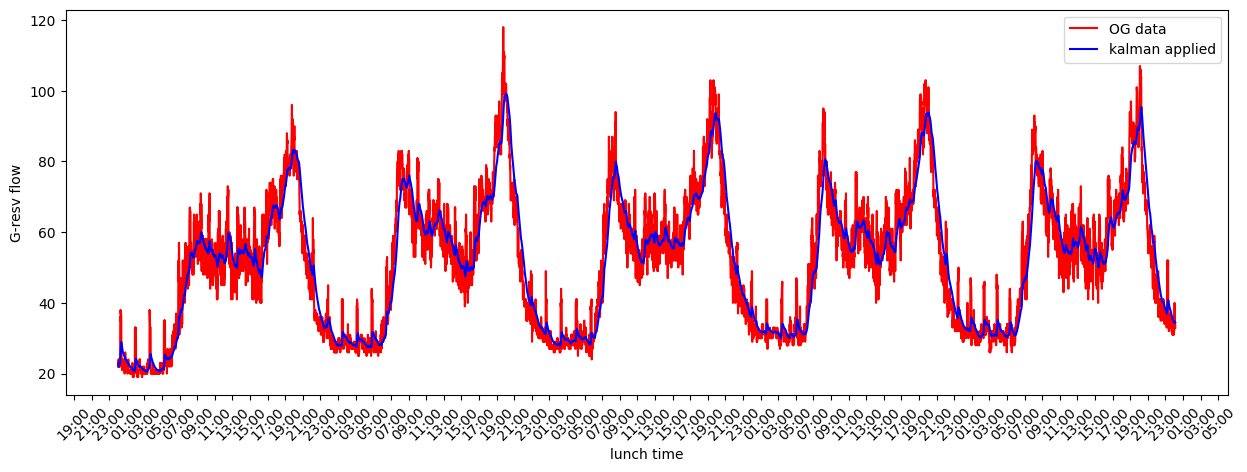

In [63]:
fig, ax = plt.subplots(figsize=(15,5))

#=========g_resv_flow
#=========g_resv_flow
#=========g_resv_flow

ax.plot(time, g_resv_flow_temp['g_resv_flow'], label='OG data', color='red')
ax.plot(time, g_resv_flow_temp['kalman_smooth'], label='kalman applied', color='blue')

#=========misc config
#=========misc config
#=========misc config
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('lunch time')
ax.set_ylabel('G-resv flow')
ax.legend()

plt.xticks(rotation=45)

plt.show()

**Learning**

In [64]:
#==========Normalization
#==========Normalization
#==========Normalization
scaler = MinMaxScaler(feature_range=(0,1))

column_to_normalize = g_resv_flow_temp.columns[-1]
g_resv_flow_temp['normalized_flow'] = scaler.fit_transform(g_resv_flow_temp[[column_to_normalize]])
g_resv_flow_temp.head()

,time,g_resv_flow,kalman_smooth,normalized_flow
1440,2023-01-02 00:03:00,22,22.000000,0.017721
1441,2023-01-02 00:04:00,24,22.998510,0.030441
1442,2023-01-02 00:05:00,22,22.665117,0.026194
1443,2023-01-02 00:06:00,24,23.000754,0.030469
1444,2023-01-02 00:07:00,24,23.202795,0.033043


In [65]:
#==========Create Sliding Window Dataset
#==========Create Sliding Window Dataset
#==========Create Sliding Window Dataset
# X.shape = (60,1) y.shape = (10,1) => X는 60분 학습 데이터, y는 10분 예측 데이터. 1분이 1개의 feature로 들어간다.  
def create_sliding_windows(data, window_size=window_size, lead_time=1, forecast_size=forecast_size):
    stop_index = len(data) - window_size - forecast_size
    X = [data[i:i+window_size] for i in range(stop_index)]
    y = [data[i+window_size : i+window_size+forecast_size] for i in range(stop_index)]
    return np.array(X), np.array(y)

g_resv_flow_values = g_resv_flow_temp['normalized_flow'].values
X,y = create_sliding_windows(g_resv_flow_values)
X = X.reshape((X.shape[0], X.shape[1],1))

In [66]:
#==========Train Test Split
#==========Train Test Split
#==========Train Test Split
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 4464
Testing samples: 1116


In [67]:


#==========Univariate LSTM with MSE Loss
#==========Univariate LSTM with MSE Loss
#==========Univariate LSTM with MSE Loss
#define model
model = Sequential([
    #1층
    LSTM(units=units, activation='relu', input_shape=(window_size,1), return_sequences=False), #2층쓸거면 트루
    Dropout(0.2),
    #2층
    #LSTM(units=int(units/2), activation='relu', return_sequences=False),
    #Dropout(0.2),

    #Output = 10분 예측
    Dense(forecast_size)
])

#use MSE for loss
model.compile(optimizer='adam', loss='mse')

#train
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size, #train sample/batch size = step per epoch
    validation_data=(X_test,y_test),
    verbose=1
)

y_pred_normalized = model.predict(X_test)

y_pred_original = scaler.inverse_transform(y_pred_normalized.reshape(-1,1).reshape(y_pred_normalized.shape))
y_test_original = scaler.inverse_transform(y_test.reshape(-1,1).reshape(y_test.shape))

mae = mean_absolute_error(y_test_original, y_pred_original)
print(f"--- Evaluation Result ---")
print(f"Mean Absolute Error: {mae:.2f} m^3/hour")
print(f"Interpretation: On average, our 10-minute prediction is off by {mae:.2f} m^3/hour.")

Epoch 1/10


c:\Users\user\miniconda3\envs\mypy\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - loss: nan - val_loss: nan
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - loss: nan - val_loss: nan
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - loss: nan - val_loss: nan
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - loss: nan - val_loss: nan
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - loss: nan - val_loss: nan
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - loss: nan - val_loss: nan
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - loss: nan - val_loss: nan
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - loss: nan - val_loss: nan
Epoch 9/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - loss: nan - val_loss: nan
Epoch 10/10
29/35 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - loss: nan

KeyboardInterrupt: 

**Evaluation**

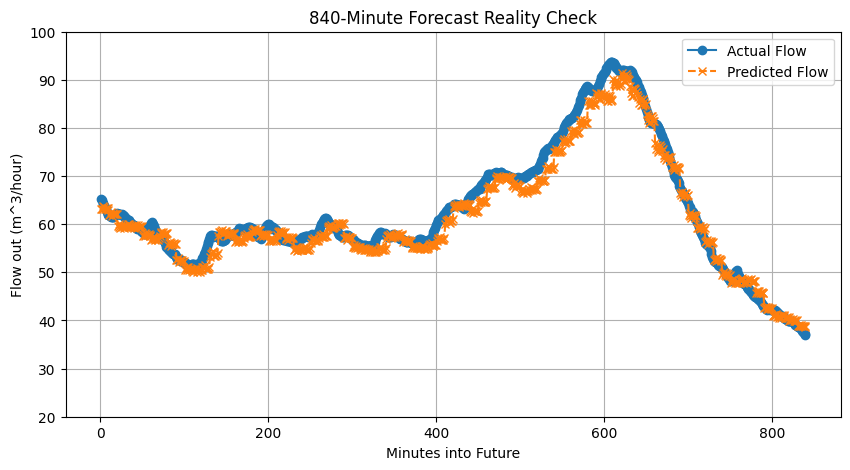

In [ ]:
sample_idx0 = 10 * 0
interval = 60 * 14 #Max = total interval (minute) * 0.2
sample_idx1 = sample_idx0 + interval
 
plt.figure(figsize=(10, 5))
plt.plot(range(1, 1+interval), y_test_original[sample_idx0:sample_idx1,0], label='Actual Flow', marker='o')
plt.plot(range(1, 1+interval), y_pred_original[sample_idx0:sample_idx1:10].reshape(-1), label='Predicted Flow', marker='x', linestyle='--')
plt.title(f"{interval}-Minute Forecast Reality Check")
plt.xlabel("Minutes into Future")
plt.ylabel("Flow out (m^3/hour)")
plt.legend()
plt.grid(True)
plt.ylim(20, 100) 
plt.show()

**y-값에 대한 설명**
- y는 (10,1) 모양이다. 0~9분의 컬럼이 있고 각 컬럼에는 그 시각에 해당하는 유출유량 정보가 들어있다.

In [ ]:
y_test_original[1]

array([62.73770492, 62.6557377 , 62.67213115, 62.70491803, 62.70491803,
       62.63934426, 62.50819672, 62.50819672, 62.49180328, 62.40983607,
       62.3442623 , 62.2295082 , 62.08196721, 61.96721311, 61.73770492,
       61.67213115, 61.50819672, 61.37704918, 61.27868852, 61.09836066,
       60.98360656, 60.75409836, 60.6557377 , 60.50819672, 60.42622951,
       60.32786885, 60.21311475, 60.13114754, 60.        , 60.        ])

- 0~99분까지의 시간 중에서 0~9분, 10~19분, ... , 90~99분 데이터를 가져와보았다. 9분과 10분, ... , 89분과 90분 데이터 사이의 괴리가 크다.

In [ ]:
y_pred_original[:100:10].reshape(1,-1)

array([[63.509727, 63.382267, 64.0008  , 63.370056, 64.01193 , 63.77894 ,
        63.545055, 63.624905, 63.805275, 63.844337, 63.28636 , 63.232994,
        63.884815, 63.1071  , 63.63658 , 63.862255, 63.165806, 63.251087,
        63.37538 , 63.333775, 63.118557, 63.08224 , 63.4864  , 62.98998 ,
        63.085526, 62.742966, 63.545956, 63.523643, 63.13199 , 63.39659 ,
        62.570934, 62.51915 , 63.00375 , 62.53204 , 63.034836, 62.853848,
        62.61333 , 62.775146, 62.86688 , 62.925705, 62.479958, 62.392433,
        62.90761 , 62.23986 , 62.690094, 62.973072, 62.315376, 62.325222,
        62.469894, 62.435535, 62.3057  , 62.25021 , 62.625965, 62.124336,
        62.25789 , 61.946   , 62.64741 , 62.676697, 62.236027, 62.573795,
        62.154396, 62.088745, 62.552937, 62.124504, 62.659706, 62.422104,
        62.11754 , 62.3792  , 62.4861  , 62.46845 , 62.045776, 62.041916,
        62.461464, 61.84836 , 62.250366, 62.625732, 61.86047 , 61.923702,
        62.070606, 62.09906 , 61.97777

- 0~9분까지의 데이터를 가져와보았다. 각 row의 첫번째 컬럼은 0분, 1분, ..., 9분을 의미한다. 이 데이터들 사이에는 괴리가 적다.

In [ ]:
y_pred_original[:10]

array([[60.668056, 60.654236, 60.819645, 60.612495, 61.025818, 60.746708,
        61.011604, 60.784897, 61.105072, 60.648663, 60.56616 , 61.002598,
        60.57339 , 60.986233, 61.038944, 60.743893, 60.5059  , 60.401764,
        60.25956 , 60.373947, 60.67804 , 60.101513, 60.27901 , 59.968872,
        60.26133 , 60.677433, 60.085125, 60.108715, 60.41507 , 59.850742],
       [60.564304, 60.539562, 60.724968, 60.518623, 60.928074, 60.65384 ,
        60.912758, 60.689705, 61.002914, 60.5528  , 60.48425 , 60.912773,
        60.484394, 60.901737, 60.95188 , 60.6569  , 60.428112, 60.318542,
        60.190464, 60.29746 , 60.593506, 60.034027, 60.216534, 59.909595,
        60.20228 , 60.60983 , 60.01593 , 60.045036, 60.3453  , 59.797108],
       [60.478577, 60.442474, 60.65095 , 60.44504 , 60.850037, 60.58136 ,
        60.833153, 60.61487 , 60.920006, 60.47692 , 60.423252, 60.843452,
        60.415943, 60.838604, 60.886345, 60.590046, 60.370975, 60.255764,
        60.142353, 60.241493, 60.529

- 따라서 각 row의 0번째 컬럼 데이터를 이용하면 그래프가 깔끔하게 그려진다.

In [ ]:
y_pred_original[:10,0]

array([60.668056, 60.564304, 60.478577, 60.40766 , 60.354313, 60.317287,
       60.296356, 60.28891 , 60.290718, 60.301014], dtype=float32)